In [1]:
!pip uninstall -y numpy scikit-surprise
!pip install "numpy<2" scikit-surprise

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 13.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 90.7 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554975 sha256=1822025449b35d735c7fb3e2b3b2600326f733bcf1a397d6f07dc87ed05fb944
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requ

In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader, SVD, KNNBasic
from surprise.model_selection import cross_validate

print("Surprise imported successfully")
print("NumPy version:", np.__version__)

Surprise imported successfully
NumPy version: 1.26.4


In [2]:
zip_path = "ratings_small.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files in zip:", z.namelist())

    csv_name = z.namelist()[0]
    with z.open(csv_name) as f:
        ratings = pd.read_csv(f)

print(ratings.head())
print("Shape:", ratings.shape)
print("Columns:", ratings.columns.tolist())

Files in zip: ['ratings_small.csv']
   userId  movieId  rating   timestamp
0       1       31     2.5  1260759144
1       1     1029     3.0  1260759179
2       1     1061     3.0  1260759182
3       1     1129     2.0  1260759185
4       1     1172     4.0  1260759205
Shape: (100004, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']


In [3]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

print("Surprise dataset loaded successfully.")

Surprise dataset loaded successfully.


In [4]:
# =========================
# Q2(c) and Q2(d)
# =========================

algorithms = {
    "PMF_like_SVD": SVD(random_state=42),
    "UserBased_CF": KNNBasic(sim_options={"name": "cosine", "user_based": True}),
    "ItemBased_CF": KNNBasic(sim_options={"name": "cosine", "user_based": False})
}

task2_results = []

for name, algo in algorithms.items():
    print(f"Running 5-fold CV for {name}...")
    cv_results = cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=True)

    task2_results.append({
        "Model": name,
        "Mean RMSE": np.mean(cv_results["test_rmse"]),
        "Mean MAE": np.mean(cv_results["test_mae"])
    })

task2_df = pd.DataFrame(task2_results)
print("\nFinal comparison table:")
print(task2_df)

Running 5-fold CV for PMF_like_SVD...
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8957  0.9098  0.8896  0.8952  0.8972  0.8975  0.0067  
MAE (testset)     0.6876  0.7005  0.6898  0.6885  0.6900  0.6913  0.0047  
Fit time          2.57    1.31    1.29    1.30    1.87    1.67    0.50    
Test time         0.23    0.20    0.11    0.10    0.32    0.19    0.08    
Running 5-fold CV for UserBased_CF...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5

In [5]:
# =========================
# Q2(e): Similarity metric comparison
# =========================

similarities = ["cosine", "msd", "pearson"]

user_metric_results = []
item_metric_results = []

# User-based CF
for sim in similarities:
    print(f"Running UserBased_CF with {sim} similarity...")
    algo = KNNBasic(sim_options={"name": sim, "user_based": True})
    cv_results = cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=False)

    user_metric_results.append({
        "Similarity": sim,
        "RMSE": np.mean(cv_results["test_rmse"]),
        "MAE": np.mean(cv_results["test_mae"])
    })

# Item-based CF
for sim in similarities:
    print(f"Running ItemBased_CF with {sim} similarity...")
    algo = KNNBasic(sim_options={"name": sim, "user_based": False})
    cv_results = cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=False)

    item_metric_results.append({
        "Similarity": sim,
        "RMSE": np.mean(cv_results["test_rmse"]),
        "MAE": np.mean(cv_results["test_mae"])
    })

user_metric_df = pd.DataFrame(user_metric_results)
item_metric_df = pd.DataFrame(item_metric_results)

print("\nUser-based CF similarity results:")
print(user_metric_df)

print("\nItem-based CF similarity results:")
print(item_metric_df)

Running UserBased_CF with cosine similarity...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running UserBased_CF with msd similarity...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Running UserBased_CF with pearson similarity...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix

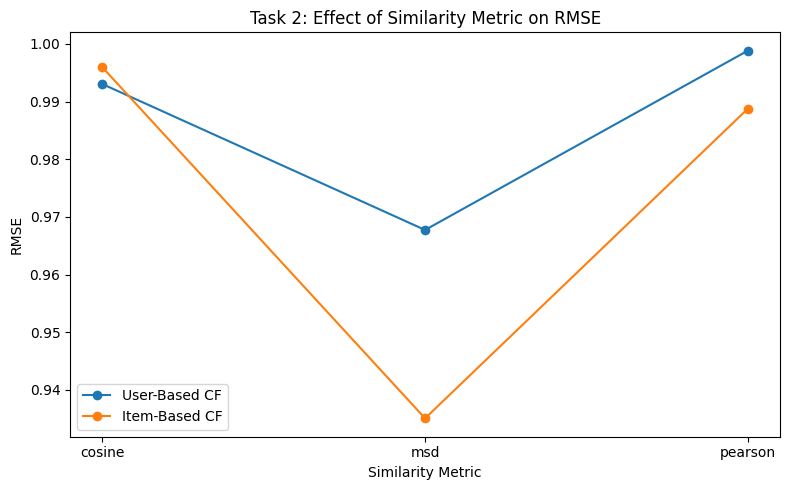

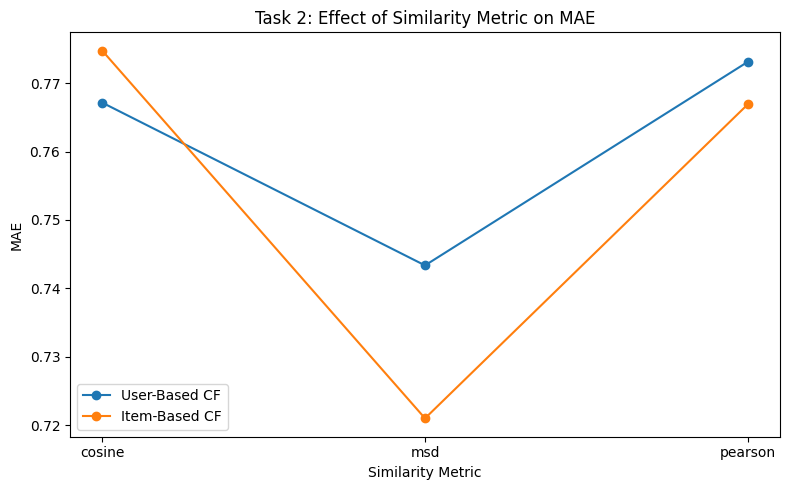

In [6]:
# RMSE plot
plt.figure(figsize=(8,5))
plt.plot(user_metric_df["Similarity"], user_metric_df["RMSE"], marker='o', label="User-Based CF")
plt.plot(item_metric_df["Similarity"], item_metric_df["RMSE"], marker='o', label="Item-Based CF")
plt.title("Task 2: Effect of Similarity Metric on RMSE")
plt.xlabel("Similarity Metric")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("task2_similarity_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

# MAE plot
plt.figure(figsize=(8,5))
plt.plot(user_metric_df["Similarity"], user_metric_df["MAE"], marker='o', label="User-Based CF")
plt.plot(item_metric_df["Similarity"], item_metric_df["MAE"], marker='o', label="Item-Based CF")
plt.title("Task 2: Effect of Similarity Metric on MAE")
plt.xlabel("Similarity Metric")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig("task2_similarity_mae.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# =========================
# Q2(f) and Q2(g): effect of number of neighbors
# =========================

k_values = [5, 10, 20, 30, 40, 50, 60, 80, 100]

user_k_results = []
item_k_results = []

for k in k_values:
    print(f"Running UserBased_CF with k={k}...")
    user_algo = KNNBasic(k=k, sim_options={"name": "cosine", "user_based": True})
    user_cv = cross_validate(user_algo, data, measures=["RMSE", "MAE"], cv=5, verbose=False)

    user_k_results.append({
        "K": k,
        "RMSE": np.mean(user_cv["test_rmse"]),
        "MAE": np.mean(user_cv["test_mae"])
    })

    print(f"Running ItemBased_CF with k={k}...")
    item_algo = KNNBasic(k=k, sim_options={"name": "cosine", "user_based": False})
    item_cv = cross_validate(item_algo, data, measures=["RMSE", "MAE"], cv=5, verbose=False)

    item_k_results.append({
        "K": k,
        "RMSE": np.mean(item_cv["test_rmse"]),
        "MAE": np.mean(item_cv["test_mae"])
    })

user_k_df = pd.DataFrame(user_k_results)
item_k_df = pd.DataFrame(item_k_results)

print("\nUser-based CF K results:")
print(user_k_df)

print("\nItem-based CF K results:")
print(item_k_df)

Running UserBased_CF with k=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running ItemBased_CF with k=5...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Running UserBased_CF with k=10...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similar

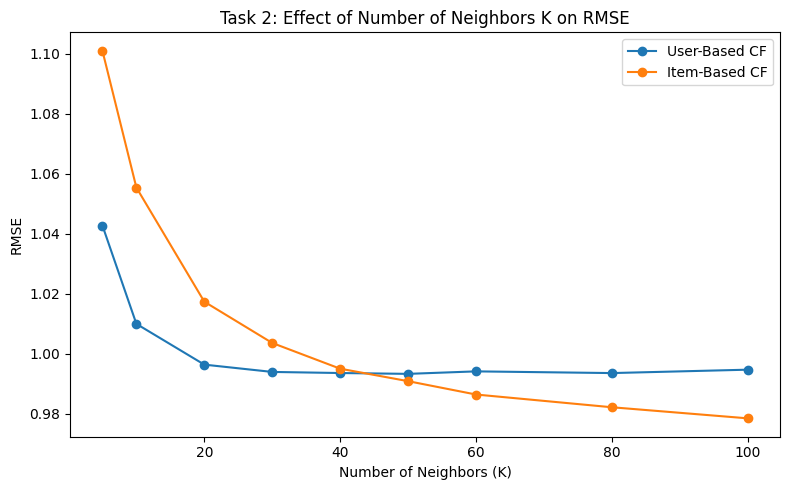

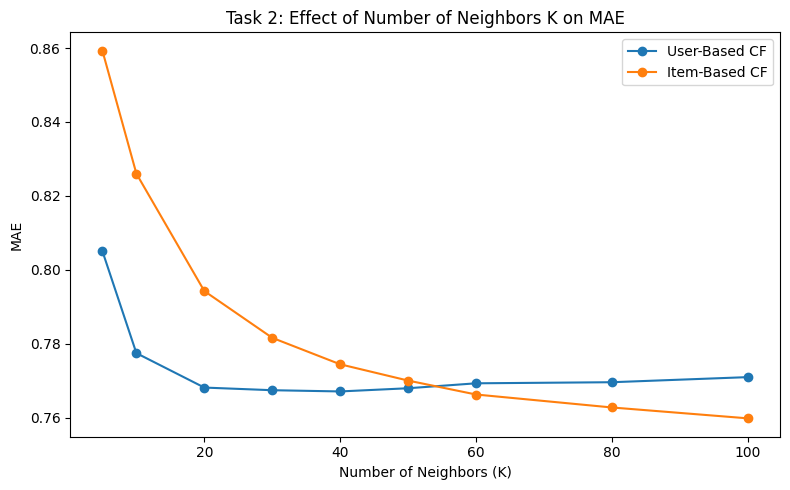

In [8]:
# RMSE vs K
plt.figure(figsize=(8,5))
plt.plot(user_k_df["K"], user_k_df["RMSE"], marker='o', label="User-Based CF")
plt.plot(item_k_df["K"], item_k_df["RMSE"], marker='o', label="Item-Based CF")
plt.title("Task 2: Effect of Number of Neighbors K on RMSE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig("task2_k_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

# MAE vs K
plt.figure(figsize=(8,5))
plt.plot(user_k_df["K"], user_k_df["MAE"], marker='o', label="User-Based CF")
plt.plot(item_k_df["K"], item_k_df["MAE"], marker='o', label="Item-Based CF")
plt.title("Task 2: Effect of Number of Neighbors K on MAE")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig("task2_k_mae.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
best_user_k = user_k_df.loc[user_k_df["RMSE"].idxmin()]
best_item_k = item_k_df.loc[item_k_df["RMSE"].idxmin()]

print("Best User-Based K:")
print(best_user_k)

print("\nBest Item-Based K:")
print(best_item_k)

Best User-Based K:
K       50.000000
RMSE     0.993255
MAE      0.767974
Name: 5, dtype: float64

Best Item-Based K:
K       100.000000
RMSE      0.978435
MAE       0.759833
Name: 8, dtype: float64
